# Synthetic bifurcation

In [1]:
import velot
import scvelo as scv

/home/user/miniforge3/envs/velot/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


VelOT: Computing velocity field
  Basis: X_umap (2D)
  Cells: 1100
  Smoothing: ON

[1/4] Building spatial-temporal windows...
  Spatial clustering: 3 clusters via KMeans on X_umap (2D)
  Built 9 window pairs across 3 clusters (skipped 0 small clusters)
  Window size: 100, step: 100

[2/4] Computing OT velocity...
  OT velocity computed: 900 cells with velocity, 200 cells without (will be filled by smoothing)

[3/4] Smoothing velocity field...
    epoch 50/300: total=1.0900 reg=1.8176 smooth=0.0011 curl=0.0101
    epoch 100/300: total=1.1201 reg=1.9051 smooth=0.0011 curl=0.0067
    epoch 150/300: total=1.1523 reg=1.9886 smooth=0.0010 curl=0.0057
    epoch 200/300: total=1.1624 reg=1.9952 smooth=0.0011 curl=0.0055
    epoch 250/300: total=1.2803 reg=2.2317 smooth=0.0010 curl=0.0047
    epoch 300/300: total=0.9255 reg=1.5566 smooth=0.0011 curl=0.0053
  Smoothing complete: final total=0.9255

[4/4] UMAP projection: SKIPPED

VelOT: Done.


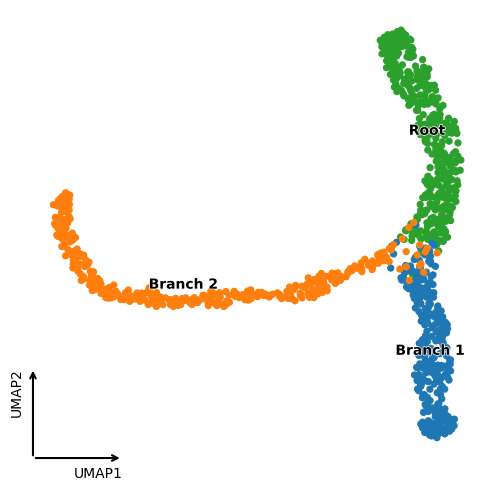

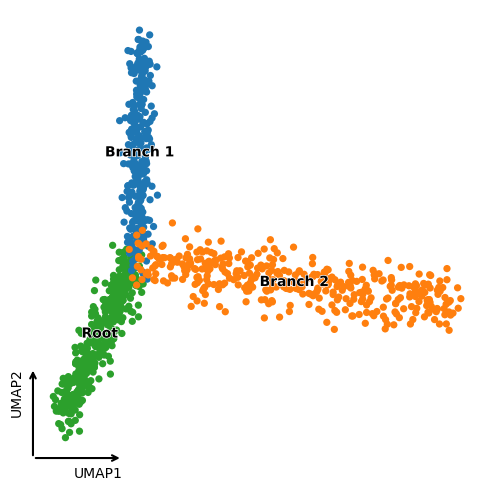

Plotting in scanpy


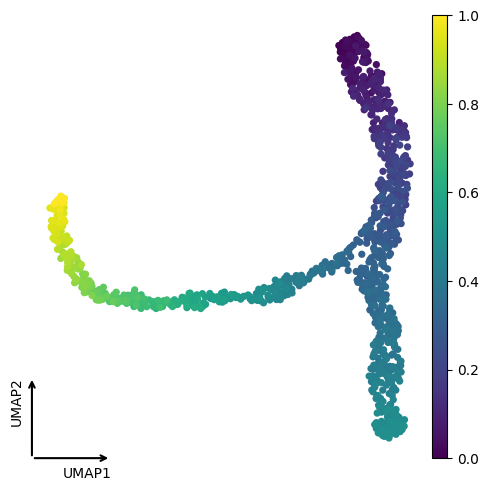

Plotting in scanpy


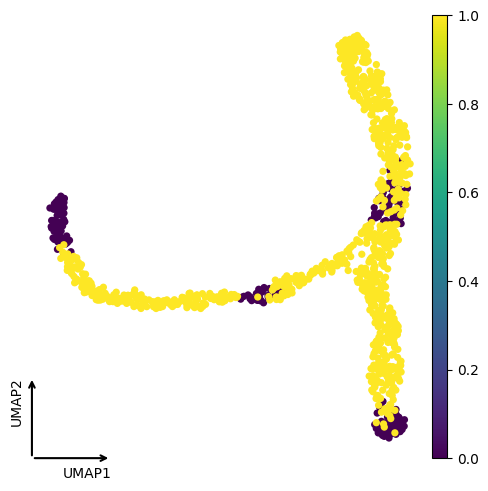

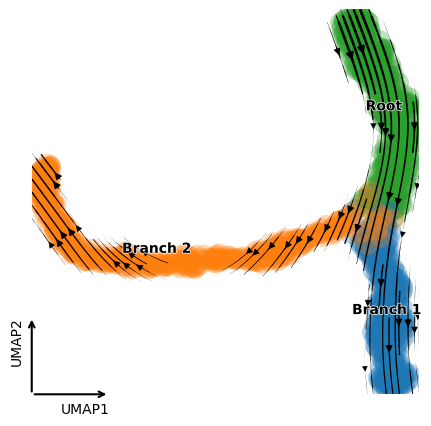

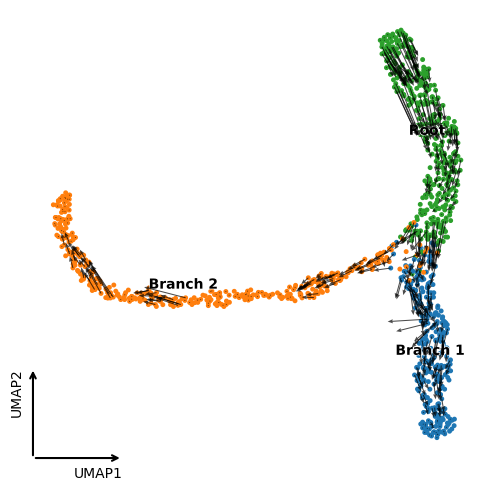

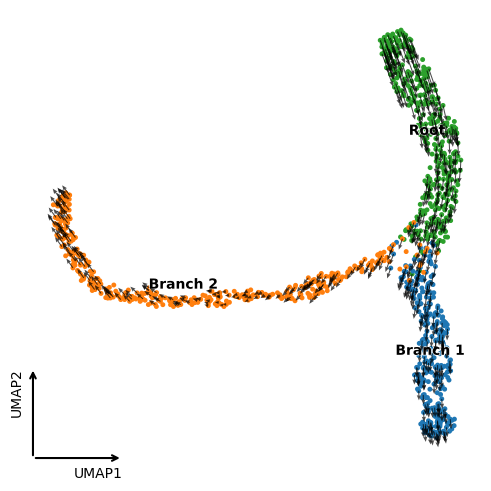

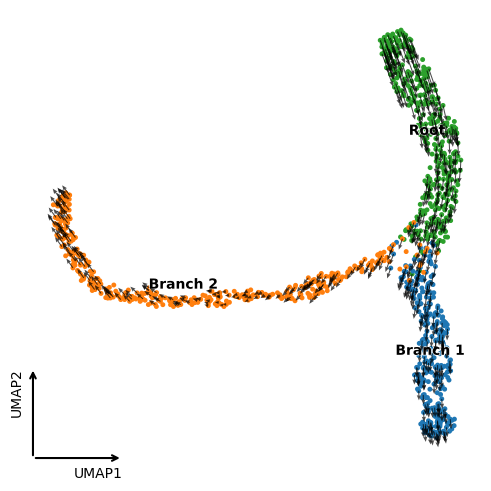

In [4]:
figures_path = "/home/user/Documents/velot/figures/figure 9"

# Load data
adata = velot.datasets.synthetic_bifurcation(400, 3, (300, 400), (5, 10), (1, -1), 0.2, 1)

# Preprocess
velot.pp.pseudotime(adata, key="true_pseudotime")
adata.obs["clusters_id"] = adata.obs["celltype"].cat.codes

# Compute velocity (full pipeline)
velot.tl.velocity(
    adata=adata,
    basis="X_umap",
    smooth=True,
    n_clusters=3,
    window_size=100,
    overlap_fraction=0,
    # spatial_key="clusters_id",
    reg=0.05, lambda_time=1, n_epochs=300, lambda_smooth=0.2, lambda_curl=0.2, lambda_divergence=0,
    project_umap=False
)

# Visualize
velot.pl.dataset_overview_simple(adata, color="celltype", title="", figsize=(5,5), inframe=True, out_legend=False, save=f"{figures_path}/figure4_a.png")
velot.pl.dataset_overview_simple(adata, color="celltype", title="", figsize=(5,5), inframe=True, out_legend=False, basis="pca")
velot.pl.dataset_overview_simple(adata, color="pseudotime", title="", save=f"{figures_path}/figure4_b.png")
velot.pl.dataset_overview_simple(adata, color="velot_confidence", title="", save=f"{figures_path}/figure4_c.png")
velot.pl.velocity_stream(adata, color="celltype", title=None, figsize=(5,5), save=f"{figures_path}/figure4_d.png")

velot.pl.velocity_quiver(adata, color="celltype", basis="umap", title="", subsample=500, figsize=(5,5), velocity_key="velot_velocity_umap_raw", show=True, save=f"{figures_path}/figure4_e.png")
velot.pl.velocity_quiver(adata, color="celltype", basis="umap", title="", subsample=500, figsize=(5,5), velocity_key="velot_velocity_umap", show=True, save=f"{figures_path}/figure4_f.png")

# velot.pl.windows(adata, pairs_to_show=(6, 7), figsize_per_panel=(4,4), show=True, save=f"{figures_path}/figure4_e.png")
# velot.pl.training_curves_single(adata, True, figsize=(7,7), save=f"{figures_path}/figure4_g.png")

# Evaluate
# edges = [
#     ('Blood progenitors 1', 'Blood progenitors 2'), 
#     ('Blood progenitors 2', 'Erythroid1'),
#     ('Erythroid1', 'Erythroid2'), 
#     ('Erythroid2', 'Erythroid3')
# ]

# results = velot.metrics.summary(adata, cluster_edges=edges, cluster_key="celltype", velocity_key="velot_velocity_umap")
# velot.pl.metric_summary(results, orientation="horizontal", layout="row", figsize=(10,9), save=f"{figures_path}/figure4_h.png")

In [ ]:
# Compute velocity (full pipeline)
# velot.tl.velocity(adata, "X_umap", True, None, 50, 0.0, spatial_key="clusters_id", reg=0.1, n_epochs=300, project_umap=False)
velot.tl.velocity(adata, "X_pca", True, None, 50, 0.0, spatial_key="clusters_id", reg=0.1, n_epochs=300, project_umap=True)

# Visualize
velot.pl.dataset_overview(adata, color="celltype", title=False, vertical=True, figsize=(7, 10), save="/home/user/Documents/velot/figures/figure1_b.png")
velot.pl.spatial_clusters(adata)
# velot.pl.windows(adata, pairs_to_show=(5, 6, 7), figsize_per_panel=(4,4), show=False, save="/home/user/Documents/velot/figures/figure1_c.png")
# velot.pl.confidence(adata)
# velot.pl.velocity_stream(adata, color="celltype", velocity_key="velot_velocity")

velot.pl.velocity_stream(adata, color="celltype")
velot.pl.training_curves(adata)

# Evaluate
edges = [
    ('Root', 'Branch_1'), 
    ('Root', 'Branch_2')
]

velot.metrics.summary(adata, cluster_edges=edges, cluster_key="celltype")

VelOT: Computing velocity field
  Basis: X_pca (2D)
  Cells: 1100
  Smoothing: ON

[1/4] Building spatial-temporal windows...
  Using precomputed spatial labels from 'clusters_id': 3 clusters
  Built 19 window pairs across 3 clusters (skipped 0 small clusters)
  Window size: 50, step: 50

[2/4] Computing OT velocity...
  OT velocity computed: 950 cells with velocity, 150 cells without (will be filled by smoothing)

[3/4] Smoothing velocity field...
    epoch 50/300: reg=0.0792 smooth=0.0005
    epoch 100/300: reg=0.0747 smooth=0.0007
    epoch 150/300: reg=0.0896 smooth=0.0010
    epoch 200/300: reg=0.0830 smooth=0.0009
    epoch 250/300: reg=0.0778 smooth=0.0009
    epoch 300/300: reg=0.0803 smooth=0.0010
  Smoothing complete: final reg=0.0803, smooth=0.0010

[4/4] Projecting to UMAP...
  Velocity projected to UMAP (1100 cells)

VelOT: Done.


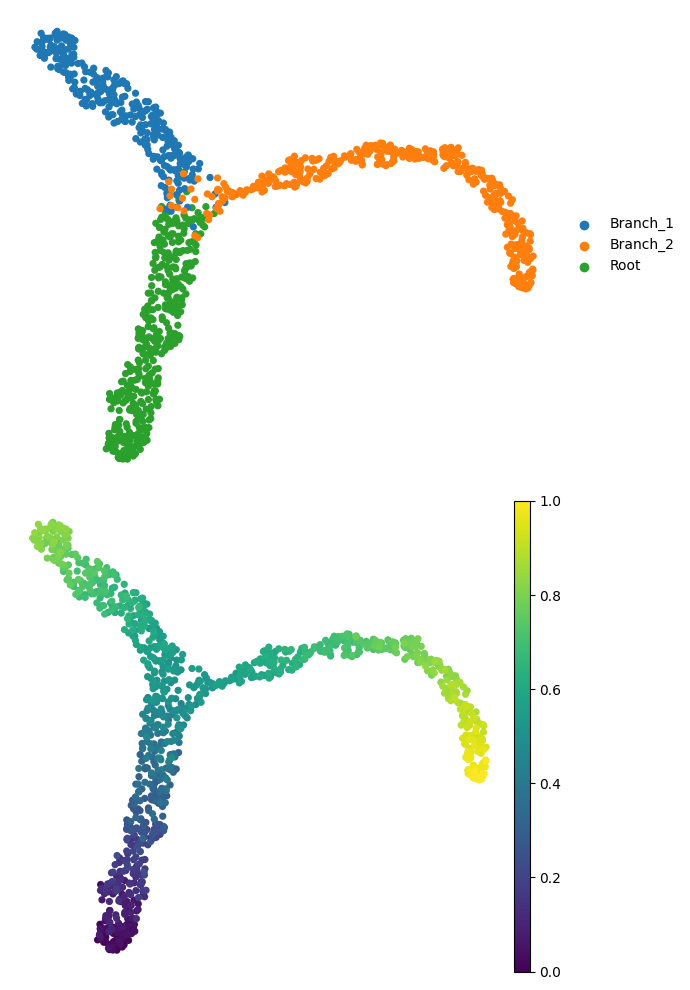

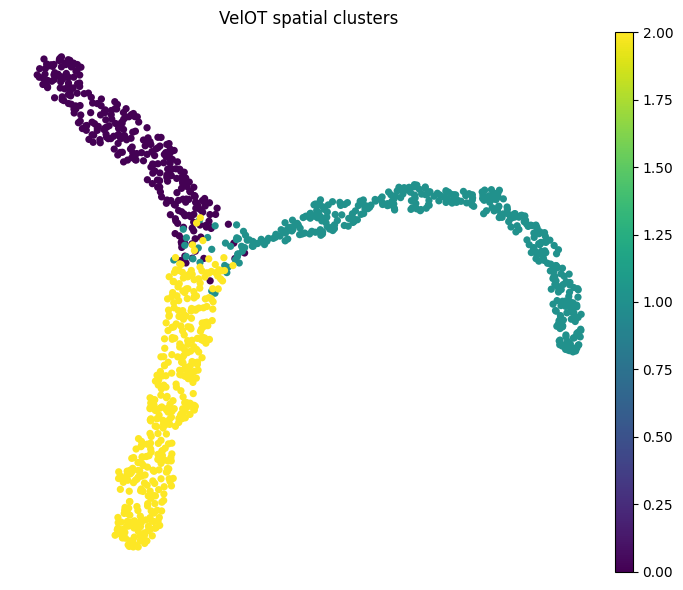

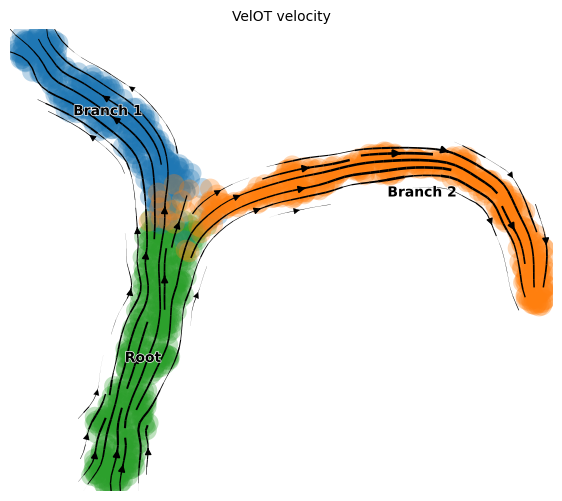

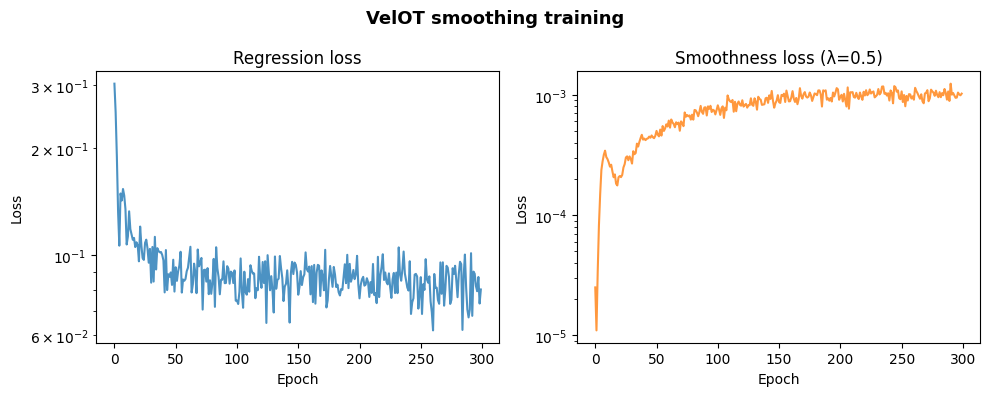

VelOT Velocity Metrics

Inner-Cluster Coherence (mean: 0.946):
                   Branch_1: 0.939
                   Branch_2: 0.966
                       Root: 0.933

Cross-Boundary Correctness (mean: 0.892):
             Root → Branch_1       : 0.917
             Root → Branch_2       : 0.867


{'iccoh': {'Branch_1': 0.9389223098754883,
  'Branch_2': 0.966068119108677,
  'Root': 0.9327126912772655},
 'iccoh_mean': 0.9459010400871436,
 'cbdir': {('Root', 'Branch_1'): 0.9174719587697131,
  ('Root', 'Branch_2'): 0.8672062986510327},
 'cbdir_mean': 0.8923391287103729}

In [2]:
# Compute velocity (full pipeline)
# velot.tl.velocity(adata, "X_umap", True, None, 50, 0.0, spatial_key="clusters_id", reg=0.1, n_epochs=300, project_umap=False)
velot.tl.velocity(adata, "X_pca", True, None, 50, 0.0, spatial_key="clusters_id", reg=0.1, n_epochs=300, project_umap=True)

# Visualize
velot.pl.dataset_overview(adata, color="celltype", title=False, vertical=True, figsize=(7, 10), save="/home/user/Documents/velot/figures/figure1_b.png")
velot.pl.spatial_clusters(adata)
# velot.pl.windows(adata, pairs_to_show=(5, 6, 7), figsize_per_panel=(4,4), show=False, save="/home/user/Documents/velot/figures/figure1_c.png")
# velot.pl.confidence(adata)
# velot.pl.velocity_stream(adata, color="celltype", velocity_key="velot_velocity")

velot.pl.velocity_stream(adata, color="celltype")
velot.pl.training_curves(adata)

# Evaluate
edges = [
    ('Root', 'Branch_1'), 
    ('Root', 'Branch_2')
]

velot.metrics.summary(adata, cluster_edges=edges, cluster_key="celltype")

3 1


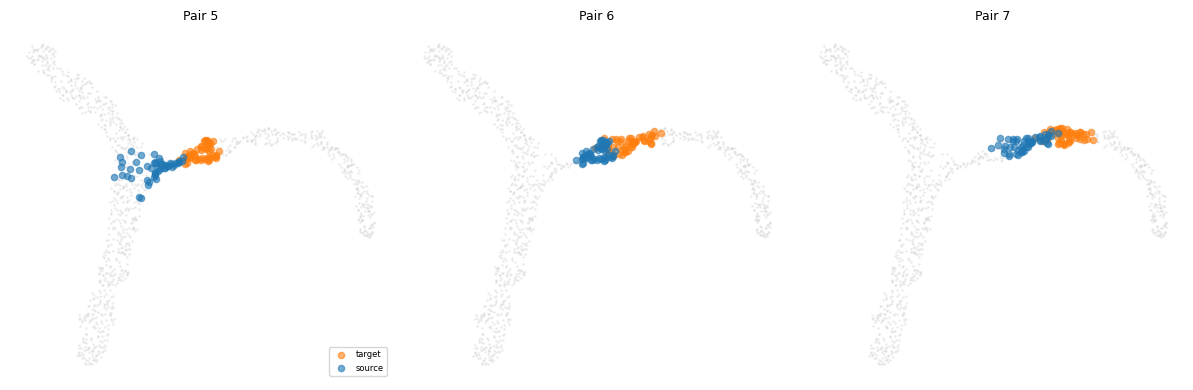

In [3]:
velot.pl.windows(adata, pairs_to_show=(5, 6, 7), figsize_per_panel=(4,4), show=False, save="/home/user/Documents/velot/figures/figure1_c.png")
# velot.pl.windows(adata, pairs_to_show=(5, 6, 7), figsize_per_panel=(4,4), show=False)

VelOT: Computing velocity field
  Basis: X_pca (2D)
  Cells: 1100
  Smoothing: ON

[1/4] Building spatial-temporal windows...
  Using precomputed spatial labels from 'clusters_id': 3 clusters
  Built 22 window pairs across 3 clusters (skipped 0 small clusters)
  Window size: 50, step: 47

[2/4] Computing OT velocity...
  OT velocity computed: 1043 cells with velocity, 57 cells without (will be filled by smoothing)

[3/4] Smoothing velocity field...
    epoch 50/300: reg=0.0735 smooth=0.0005
    epoch 100/300: reg=0.0731 smooth=0.0009
    epoch 150/300: reg=0.0643 smooth=0.0011
    epoch 200/300: reg=0.0798 smooth=0.0011
    epoch 250/300: reg=0.0694 smooth=0.0011
    epoch 300/300: reg=0.0750 smooth=0.0012
  Smoothing complete: final reg=0.0750, smooth=0.0012

[4/4] Projecting to UMAP...
  Velocity projected to UMAP (1100 cells)

VelOT: Done.


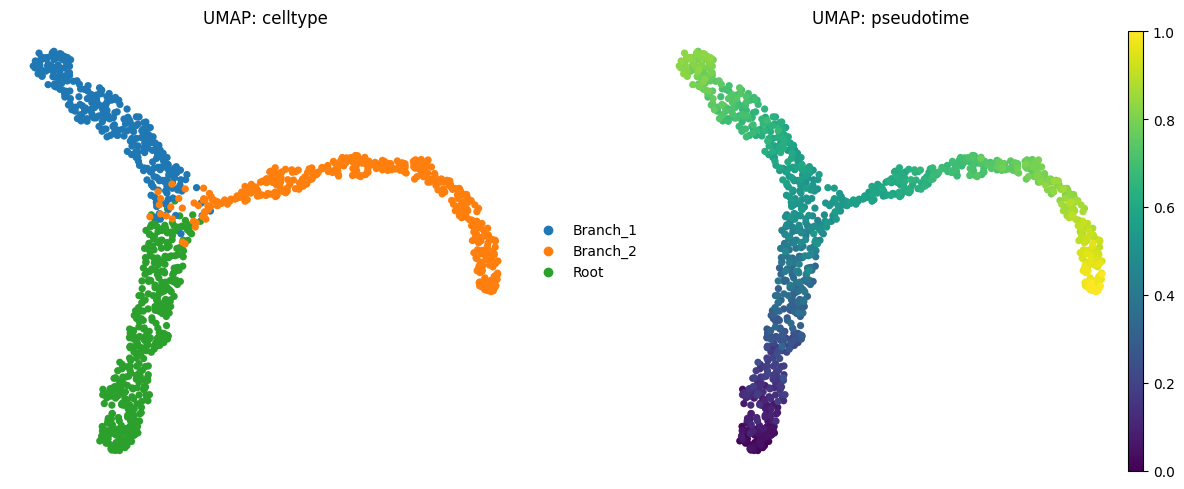

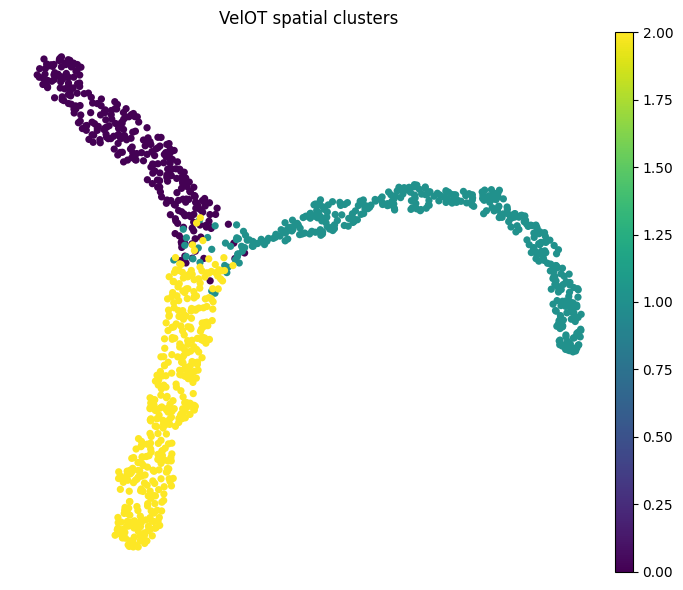

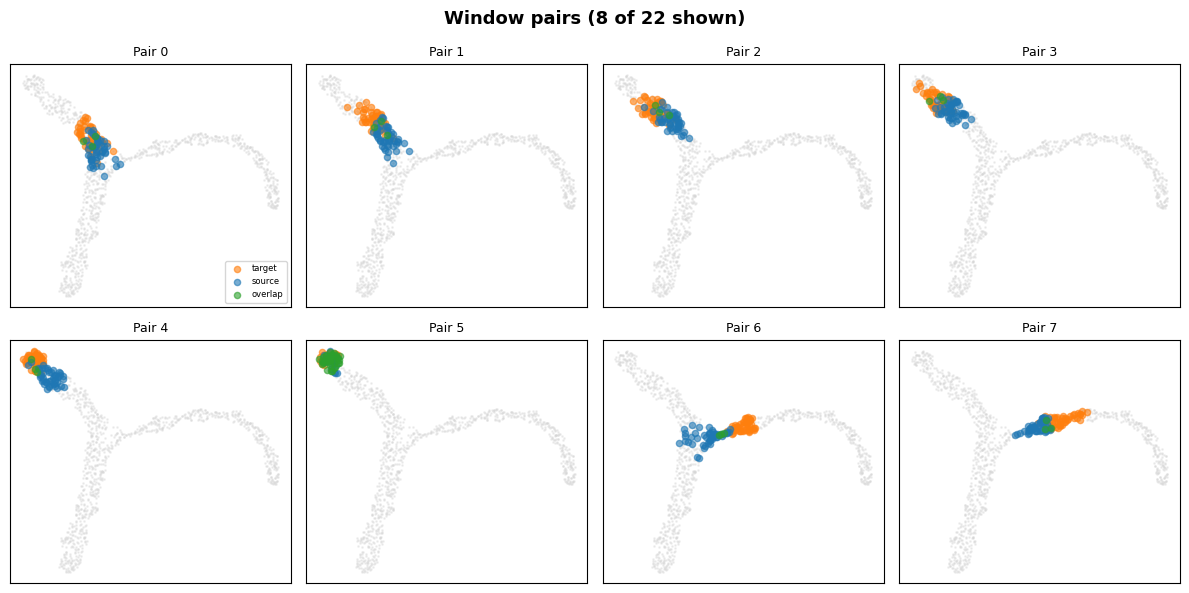

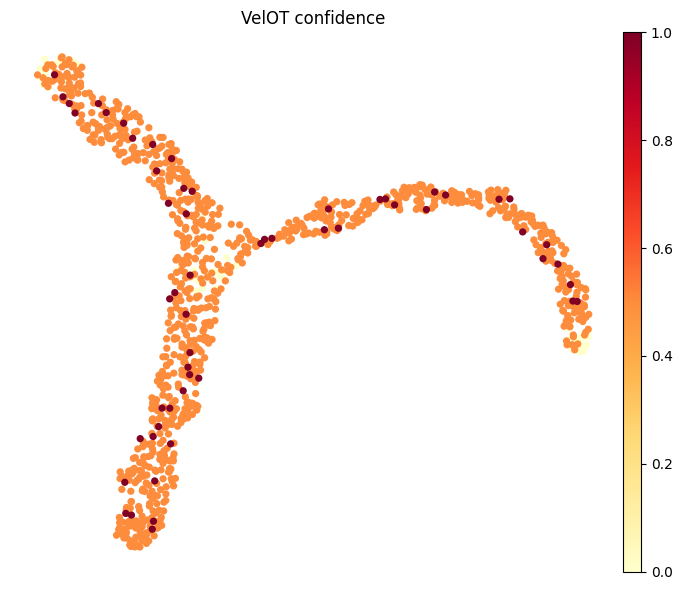

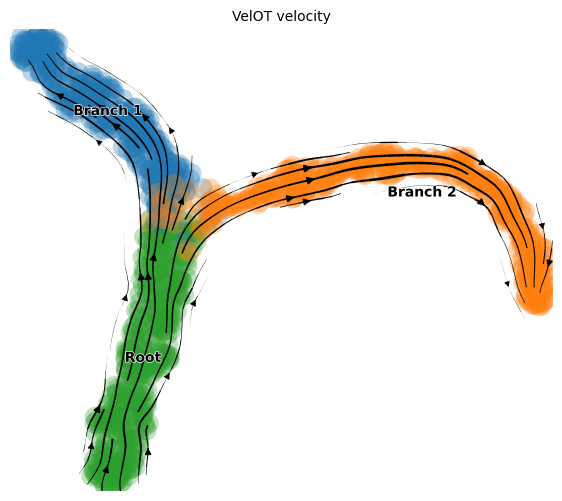

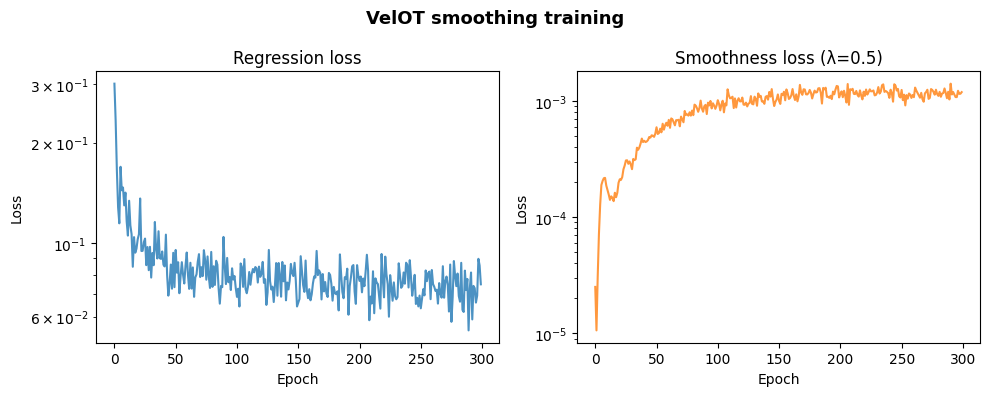

VelOT Velocity Metrics

Inner-Cluster Coherence (mean: 0.939):
                   Branch_1: 0.930
                   Branch_2: 0.957
                       Root: 0.931

Cross-Boundary Correctness (mean: 0.892):
             Root → Branch_1       : 0.913
             Root → Branch_2       : 0.870


{'iccoh': {'Branch_1': 0.9295398984352747,
  'Branch_2': 0.957172718346119,
  'Root': 0.9308657982945442},
 'iccoh_mean': 0.9391928050253125,
 'cbdir': {('Root', 'Branch_1'): 0.9133879224264477,
  ('Root', 'Branch_2'): 0.8701753792598649},
 'cbdir_mean': 0.8917816508431563}

In [9]:
# Compute velocity (full pipeline)
velot.tl.velocity(adata, "X_pca", True, None, 50, 0.05, spatial_key="clusters_id", reg=0.1, n_epochs=300, project_umap=True)
# velot.tl.velocity(adata, "X_pca", True, None, 100, 0.05, spatial_key="clusters_id", reg=0.1, n_epochs=300, project_umap=True)

# Visualize
velot.pl.dataset_overview(adata, color="celltype")
velot.pl.spatial_clusters(adata)
velot.pl.windows(adata, max_show=8)
velot.pl.confidence(adata)
velot.pl.velocity_stream(adata, color="celltype")
velot.pl.training_curves(adata)

# Evaluate
edges = [
    ('Root', 'Branch_1'), 
    ('Root', 'Branch_2')
]

velot.metrics.summary(adata, cluster_edges=edges, cluster_key="celltype")

# Synthetic helicoidal

In [ ]:
import velot
import scvelo as scv

# Load data
# adata = velot.datasets.erythroid()
adata = velot.datasets.synthetic_cycle((1000, 2000, 4000, 2000), n_rotations=3, x_amplitude=3, z_drift=20, noise_level=0.3, extra_dimensions=1)

# scv.pp.filter_and_normalize(adata, min_shared_counts=200, min_shared_cells=10)
adata.obsm["X_X"] = adata.X.copy()

# Preprocess
# adata_process = velot.pp.prepare(adata, root_cluster="Blood progenitors 1", cluster_key="celltype")

# velot.pp.normalize(adata)
# velot.pp.select_genes(adata, n_hvg=3000)
velot.pp.scale(adata)
# velot.pp.pca(adata, n_pcs=200)
# velot.pp.neighbors(adata)
# velot.pp.umap(adata)
# velot.pp.pseudotime(adata, root_cluster="Phase_1", cluster_key="celltype")
velot.pp.pseudotime(adata, key="true_pseudotime")
adata.obs["clusters"] = adata.obs["celltype"].cat.codes

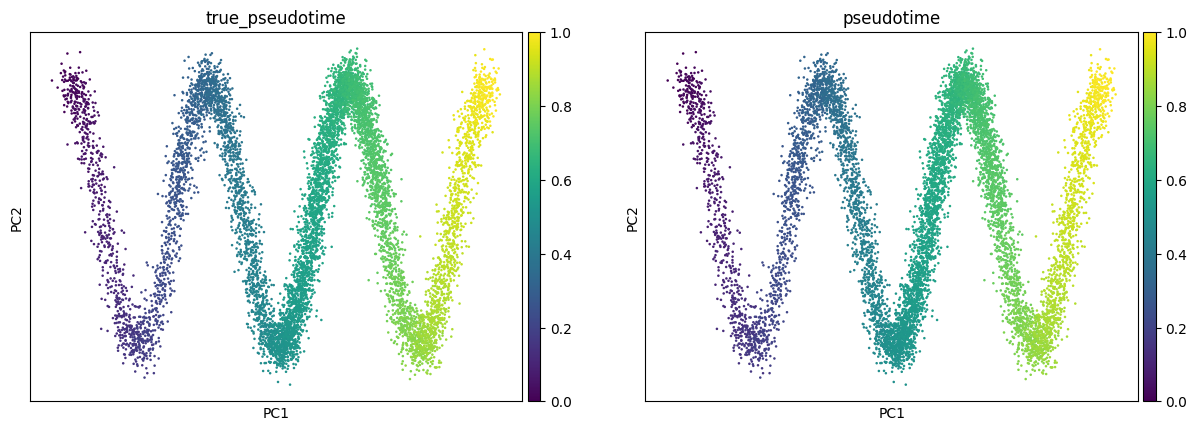

In [11]:
import scanpy as sc
sc.pl.pca(adata, color=["true_pseudotime", "pseudotime"])

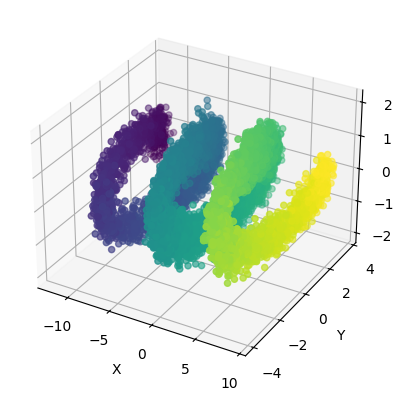

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # optional in newer versions
import numpy as np

# Example data
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(adata.obsm["X_pca"][:,0], adata.obsm["X_pca"][:,1], adata.obsm["X_pca"][:,2], c=adata.obs["true_pseudotime"])

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.show()

In [13]:
adata_original = adata.copy()

VelOT: Computing velocity field
  Basis: X_pca (3D)
  Cells: 9000
  Smoothing: ON

[1/4] Building spatial-temporal windows...
  Using precomputed spatial labels from 'clusters': 4 clusters
  Built 47 window pairs across 4 clusters (skipped 0 small clusters)
  Window size: 200, step: 180

[2/4] Computing OT velocity...
  OT velocity computed: 8540 cells with velocity, 460 cells without (will be filled by smoothing)

[3/4] Smoothing velocity field...
    epoch 50/200: reg=0.2699 smooth=0.0019
    epoch 100/200: reg=0.2975 smooth=0.0017
    epoch 150/200: reg=0.2234 smooth=0.0019
    epoch 200/200: reg=0.2347 smooth=0.0015
  Smoothing complete: final reg=0.2347, smooth=0.0015

[4/4] Projecting to UMAP...
  Velocity projected to UMAP (9000 cells)

VelOT: Done.


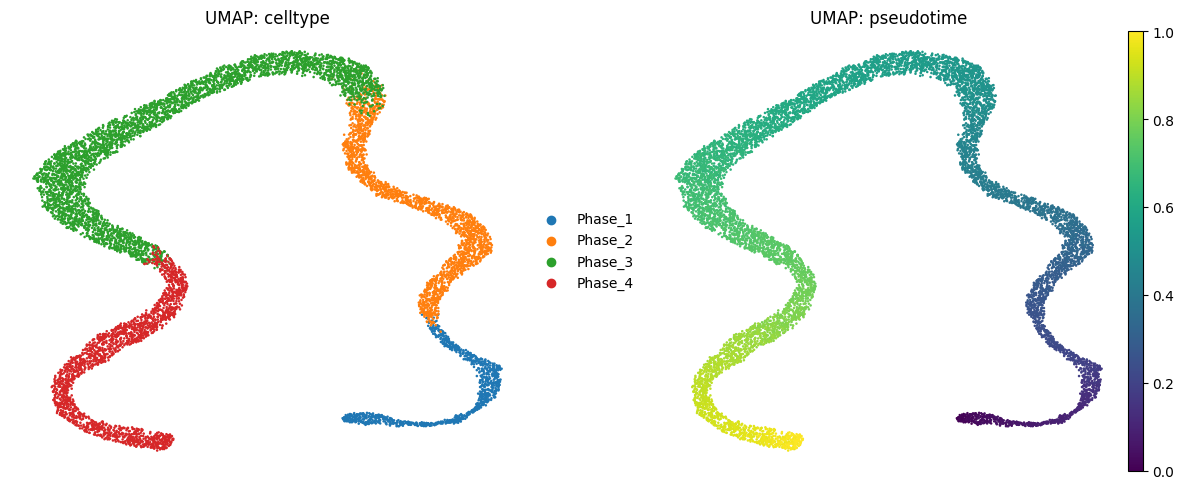

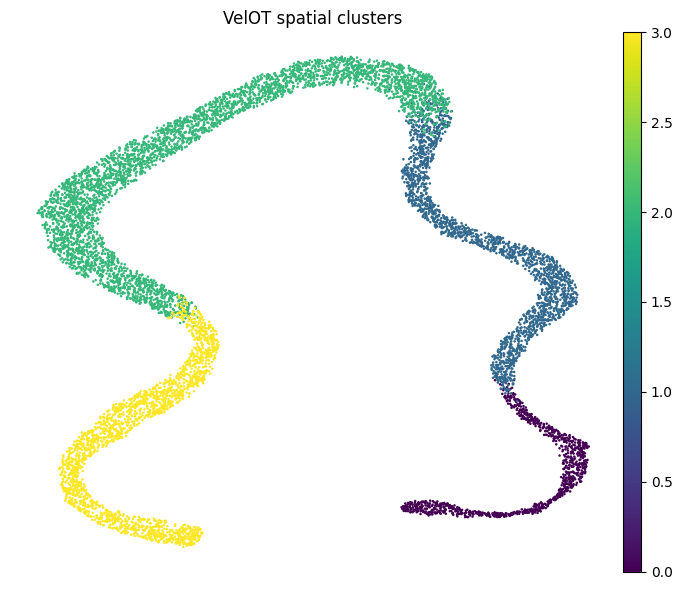

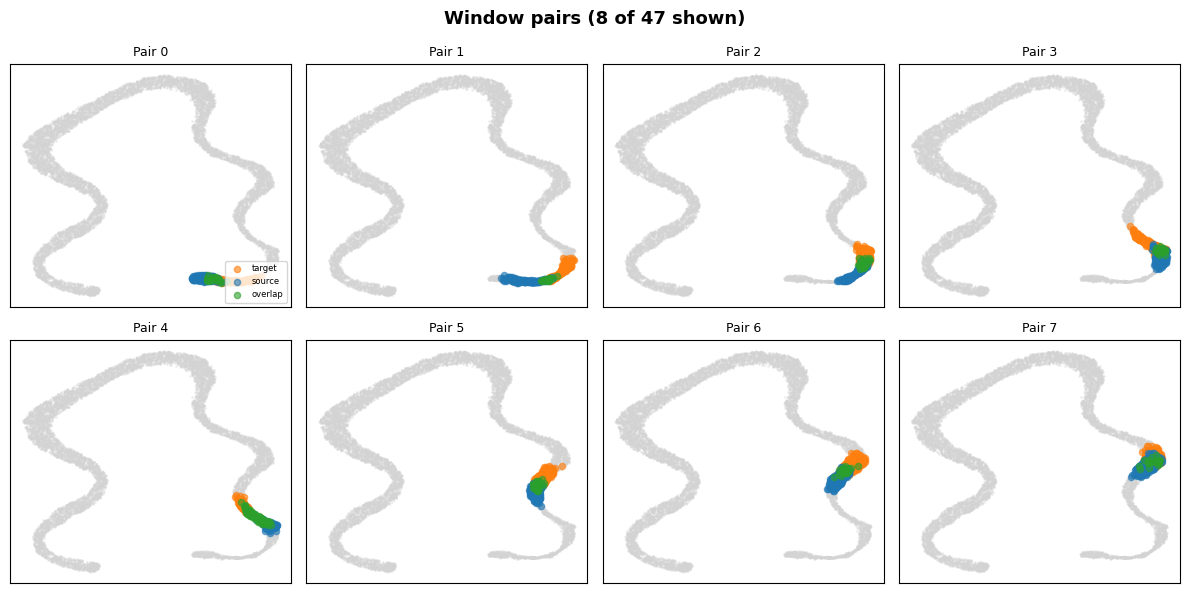

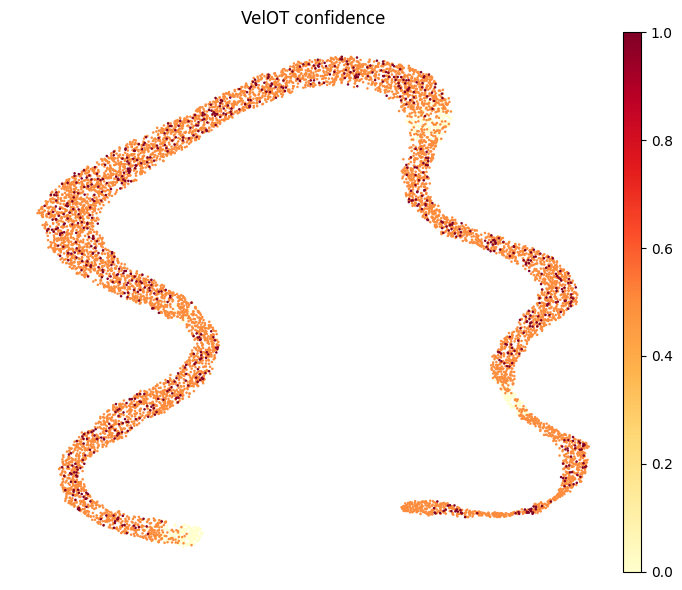

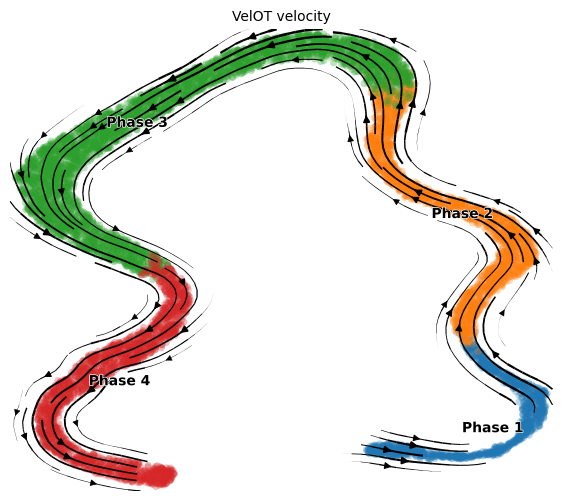

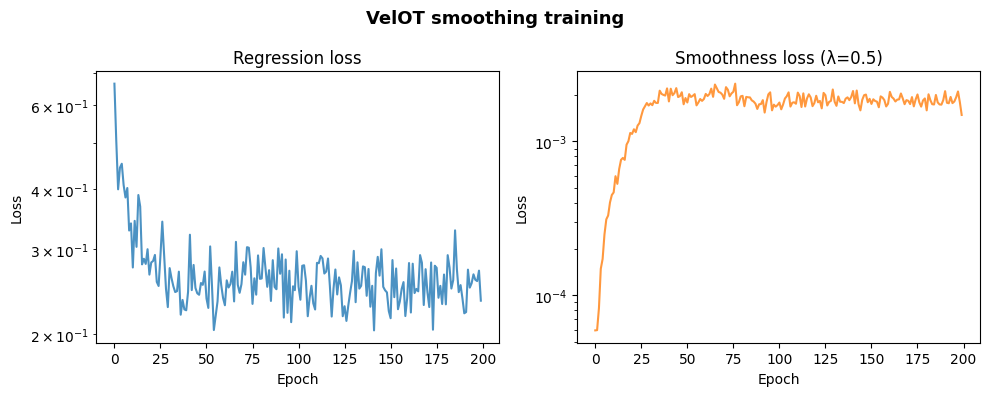

VelOT Velocity Metrics

Inner-Cluster Coherence (mean: 0.944):
                    Phase_1: 0.925
                    Phase_2: 0.960
                    Phase_3: 0.960
                    Phase_4: 0.933

Cross-Boundary Correctness (mean: 0.867):
          Phase_1 → Phase_2        : 0.919
          Phase_2 → Phase_3        : 0.790
          Phase_3 → Phase_4        : 0.892


{'iccoh': {'Phase_1': 0.9248445985913276,
  'Phase_2': 0.9601223506778479,
  'Phase_3': 0.959514923274517,
  'Phase_4': 0.9330077876448631},
 'iccoh_mean': 0.9443724150471389,
 'cbdir': {('Phase_1', 'Phase_2'): 0.9188702307620102,
  ('Phase_2', 'Phase_3'): 0.7901461908425129,
  ('Phase_3', 'Phase_4'): 0.892348904651751},
 'cbdir_mean': 0.867121775418758}

In [14]:
# Compute velocity (full pipeline)
velot.tl.velocity(adata, "X_pca", True, None, 200, 0.1, spatial_key="clusters")

# Visualize
velot.pl.dataset_overview(adata, color="celltype")
velot.pl.spatial_clusters(adata)
velot.pl.windows(adata, max_show=8)
velot.pl.confidence(adata)
velot.pl.velocity_stream(adata, color="celltype")
velot.pl.training_curves(adata)

# Evaluate
# edges = [
#     ("Ductal", "Ngn3 low EP"),
#     ("Ngn3 low EP", "Ngn3 high EP"),
# ]
# edges = [
#     ('Blood progenitors 1', 'Blood progenitors 2'), 
#     ('Blood progenitors 2', 'Erythroid1'),
#     ('Erythroid1', 'Erythroid2'), 
#     ('Erythroid2', 'Erythroid3')
# ]
edges = [
    ('Phase_1', 'Phase_2'),
    ('Phase_2', 'Phase_3'), 
    ('Phase_3', 'Phase_4')
]
velot.metrics.summary(adata, cluster_edges=edges, cluster_key="celltype")

In [16]:
adata_smooth = adata.copy()
adata_smooth

AnnData object with n_obs × n_vars = 9000 × 4
    obs: 'celltype', 'true_pseudotime', 'pseudotime', 'clusters', 'velot_spatial_cluster', 'velot_confidence'
    var: 'mean', 'std'
    uns: 'pca', 'neighbors', 'umap', 'velot_windows', 'velot_smoothing', 'celltype_colors'
    obsm: 'X_spatial_true', 'X_pca', 'X_umap', 'X_X', 'velot_velocity', 'velot_velocity_raw', 'velocity_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [17]:
adata = adata_original.copy()
adata

AnnData object with n_obs × n_vars = 9000 × 4
    obs: 'celltype', 'true_pseudotime', 'pseudotime', 'clusters'
    var: 'mean', 'std'
    uns: 'pca', 'neighbors', 'umap'
    obsm: 'X_spatial_true', 'X_pca', 'X_umap', 'X_X'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

VelOT: Computing velocity field
  Basis: X_pca (3D)
  Cells: 9000
  Smoothing: OFF

[1/4] Building spatial-temporal windows...
  Using precomputed spatial labels from 'clusters': 4 clusters
  Built 47 window pairs across 4 clusters (skipped 0 small clusters)
  Window size: 200, step: 180

[2/4] Computing OT velocity...
  OT velocity computed: 8540 cells with velocity, 460 cells without (will be filled by smoothing)

[3/4] Smoothing: SKIPPED

[4/4] Projecting to UMAP...
  Velocity projected to UMAP (9000 cells)

VelOT: Done.


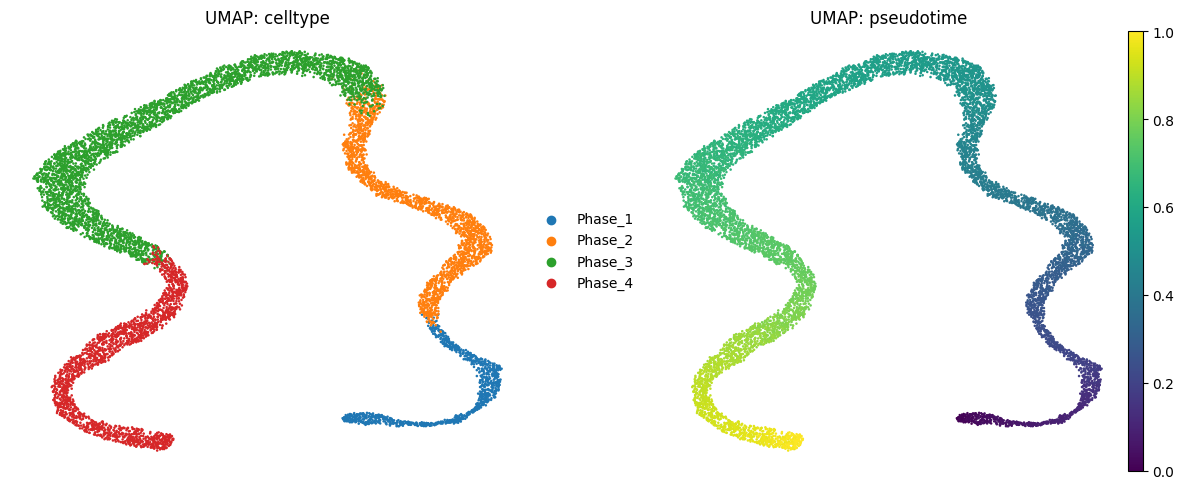

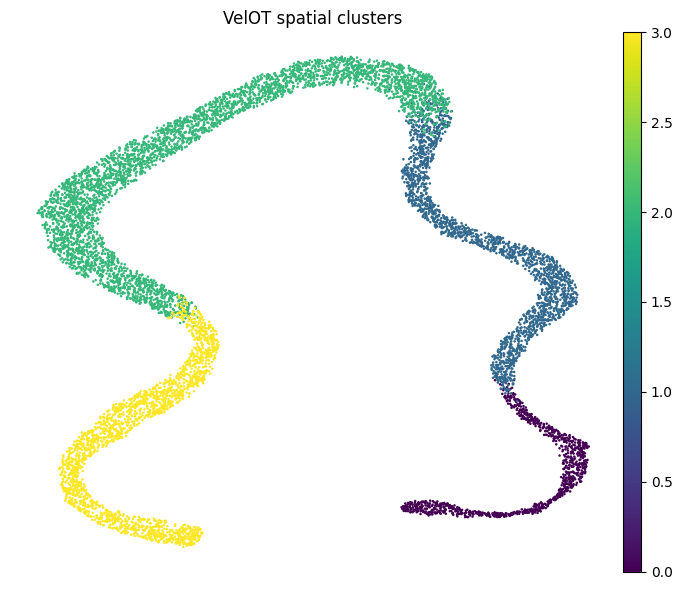

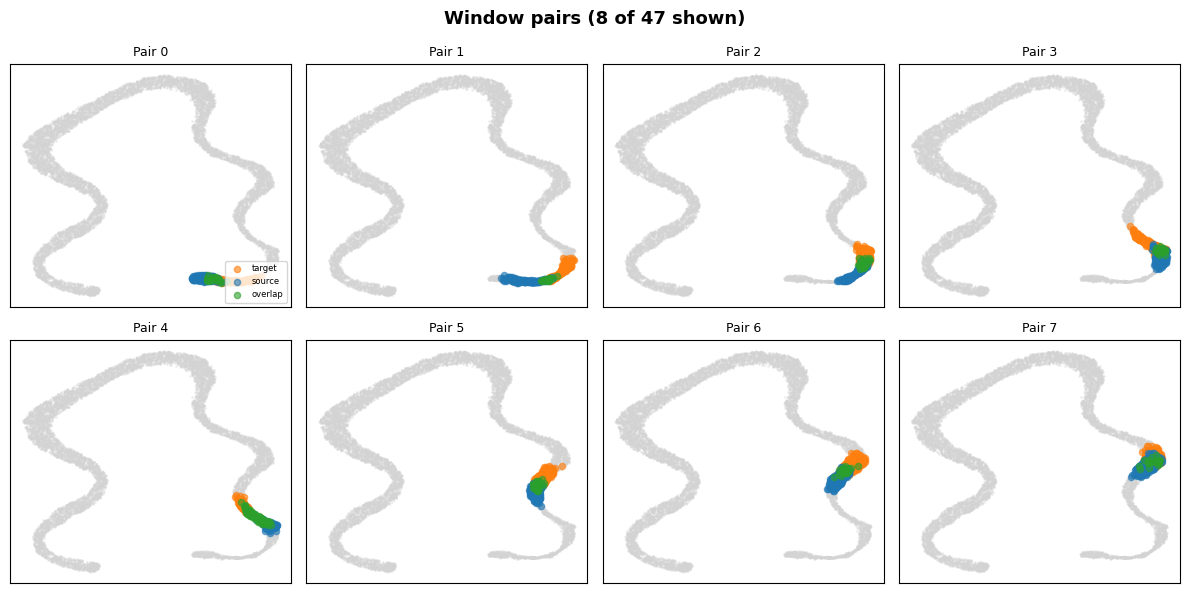

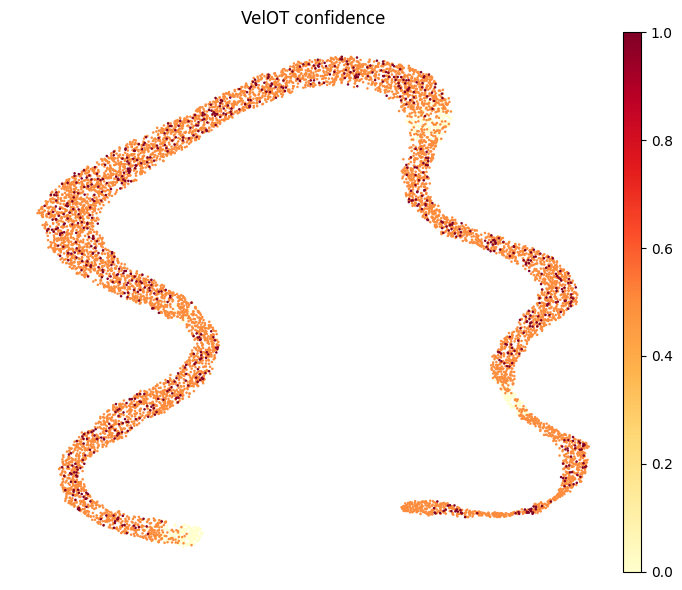

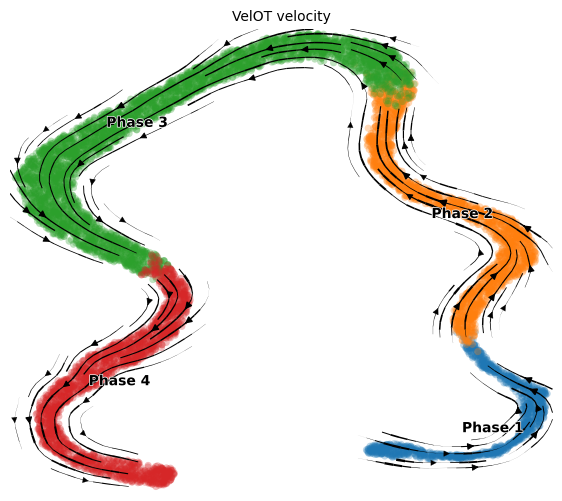

VelOT Velocity Metrics

Inner-Cluster Coherence (mean: 0.645):
                    Phase_1: 0.528
                    Phase_2: 0.629
                    Phase_3: 0.809
                    Phase_4: 0.614

Cross-Boundary Correctness (mean: 0.394):
          Phase_1 → Phase_2        : 0.153
          Phase_2 → Phase_3        : 0.318
          Phase_3 → Phase_4        : 0.711


{'iccoh': {'Phase_1': 0.5278884521946311,
  'Phase_2': 0.6287308709137142,
  'Phase_3': 0.8091234811227769,
  'Phase_4': 0.6135359794571996},
 'iccoh_mean': 0.6448196959220804,
 'cbdir': {('Phase_1', 'Phase_2'): 0.15331196581196582,
  ('Phase_2', 'Phase_3'): 0.31815792951623245,
  ('Phase_3', 'Phase_4'): 0.7114225389421446},
 'cbdir_mean': 0.3942974780901143}

In [20]:
# Compute velocity (full pipeline)
velot.tl.velocity(adata, "X_pca", False, None, 200, 0.1, spatial_key="clusters")

# Visualize
velot.pl.dataset_overview(adata, color="celltype")
velot.pl.spatial_clusters(adata)
velot.pl.windows(adata, max_show=8)
velot.pl.confidence(adata)
velot.pl.velocity_stream(adata, color="celltype")
# velot.pl.training_curves(adata)

# Evaluate
# edges = [
#     ("Ductal", "Ngn3 low EP"),
#     ("Ngn3 low EP", "Ngn3 high EP"),
# ]
# edges = [
#     ('Blood progenitors 1', 'Blood progenitors 2'), 
#     ('Blood progenitors 2', 'Erythroid1'),
#     ('Erythroid1', 'Erythroid2'), 
#     ('Erythroid2', 'Erythroid3')
# ]
edges = [
    ('Phase_1', 'Phase_2'),
    ('Phase_2', 'Phase_3'), 
    ('Phase_3', 'Phase_4')
]
velot.metrics.summary(adata, cluster_edges=edges, cluster_key="celltype")

In [1]:
import velot
import numpy as np
import scanpy as sc
import scvelo as scv

figures_path = "/home/user/Documents/velot/figures/figure 3"

# Load data
try:
    adata = sc.read_h5ad("/home/user/Documents/velot/notebooks/data/Synthetic/cycle.h5ad")
except:
    adata = velot.datasets.synthetic_cycle((1000, 2000, 4000, 2000), n_rotations=3, x_amplitude=3, z_drift=20, noise_level=0.3, extra_dimensions=1)
    adata.write("/home/user/Documents/velot/notebooks/data/Synthetic/cycle.h5ad")

/home/user/miniforge3/envs/velot/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


VelOT: Computing velocity field
  Basis: X_pca (3D)
  Cells: 9000
  Smoothing: ON

[1/4] Building spatial-temporal windows...
  Spatial clustering: 1 clusters via KMeans on X_pca (3D)
  Built 99 window pairs across 1 clusters (skipped 0 small clusters)
  Window size: 100, step: 90

[2/4] Computing OT velocity...
  OT velocity computed: 8920 cells with velocity, 80 cells without (will be filled by smoothing)

[3/4] Smoothing velocity field...
    epoch 50/300: total=0.9869 reg=0.1033 smooth=0.0011
    epoch 100/300: total=1.1290 reg=0.1181 smooth=0.0011
    epoch 150/300: total=1.0255 reg=0.1073 smooth=0.0012
    epoch 200/300: total=0.9231 reg=0.0966 smooth=0.0010
    epoch 250/300: total=0.8980 reg=0.0940 smooth=0.0011
    epoch 300/300: total=0.7648 reg=0.0800 smooth=0.0011
  Smoothing complete: final total=0.7648

[4/4] Projecting to UMAP...
  Velocity projected to UMAP (9000 cells)

VelOT: Done.


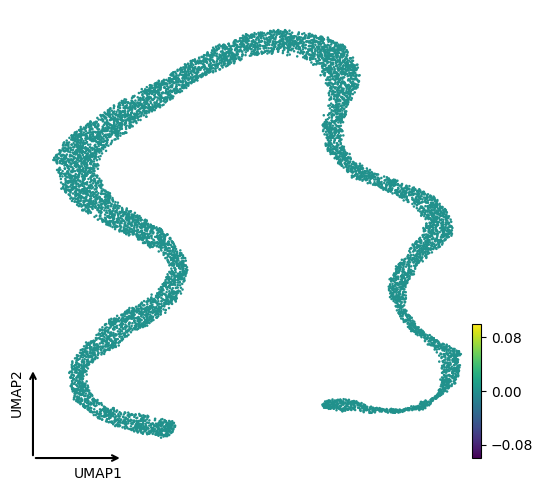

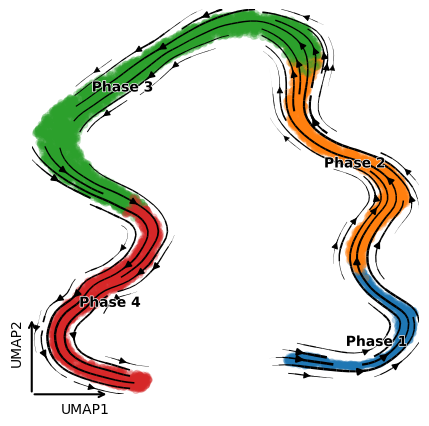

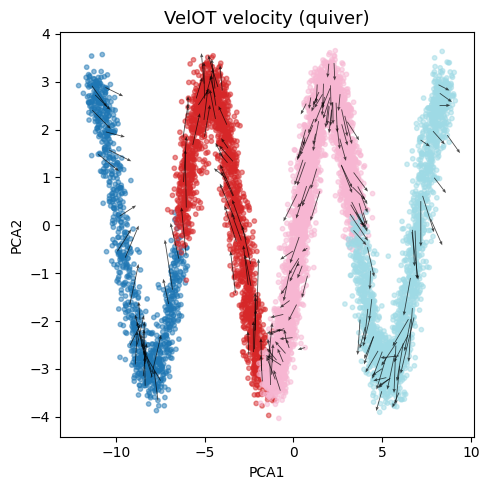

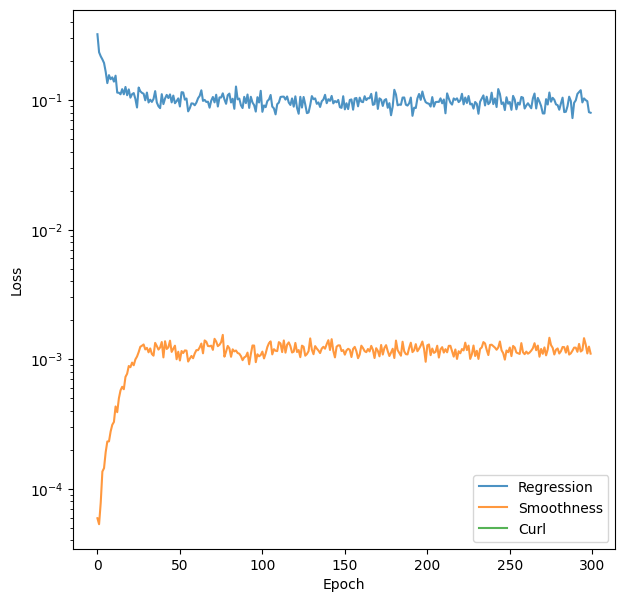

VelOT Velocity Metrics

Inner-Cluster Coherence (mean: 0.953):
                    Phase_1: 0.960
                    Phase_2: 0.963
                    Phase_3: 0.953
                    Phase_4: 0.935

Cross-Boundary Correctness (mean: 0.868):
          Phase_1 → Phase_2        : 0.921
          Phase_2 → Phase_3        : 0.789
          Phase_3 → Phase_4        : 0.894


In [64]:
# Preprocess
velot.pp.pseudotime(adata, key="true_pseudotime")
adata.obs["clusters_id"] = adata.obs["celltype"].cat.codes

# Compute velocity (full pipeline)
# velot.tl.velocity(
#     adata=adata,
#     basis="X_pca",
#     smooth=True,
#     n_clusters=None,
#     window_size=150,
#     overlap_fraction=0,
#     spatial_key="clusters_id",
#     reg=0.05, lambda_time=1, n_epochs=300, lambda_smooth=0, lambda_curl=1, lambda_divergence=0,
#     project_umap=True
# )

velot.tl.velocity(
    adata=adata,
    basis="X_pca",
    smooth=True,
    n_clusters=1,
    window_size=100,
    overlap_fraction=0.1,
    spatial_key=None,
    reg=0.05, lambda_time=1, n_epochs=300, lambda_smooth=0.0, lambda_curl=0.0, lambda_divergence=0,
    project_umap=True
)

# # Visualize
# velot.pl.dataset_overview_simple(adata, color="celltype", title="", figsize=(5,5), inframe=True, out_legend=False, save=f"{figures_path}/figure2_a.png")
# velot.pl.dataset_overview_simple(adata, color="pseudotime", title="", save=f"{figures_path}/figure2_b.png")
# velot.pl.dataset_overview_simple(adata, color="velot_confidence", title="", save=f"{figures_path}/figure2_c.png")
# velot.pl.velocity_stream(adata, color="celltype", title=None, figsize=(5,5), save=f"{figures_path}/figure2_d.png")
# velot.pl.windows(adata, pairs_to_show=(6, 7, 8, 9), figsize_per_panel=(4,4), show=True, save=f"{figures_path}/figure2_e.png")
# velot.pl.training_curves_single(adata, True, figsize=(7,7), save=f"{figures_path}/figure2_f.png")

velot.pl.dataset_overview_simple(adata, color="velot_spatial_cluster", title="", figsize=(5,5), inframe=True, out_legend=False)
velot.pl.velocity_stream(adata, color="celltype", title=None, figsize=(5,5))
velot.pl.velocity_quiver(adata, color="celltype", basis="pca", subsample=200, figsize=(5,5))
velot.pl.training_curves_single(adata, True, figsize=(7,7))

# Evaluate
edges = [
    ('Phase_1', 'Phase_2'),
    ('Phase_2', 'Phase_3'), 
    ('Phase_3', 'Phase_4')
]
results = velot.metrics.summary(adata, cluster_edges=edges, cluster_key="celltype")
# velot.pl.metric_summary(results, orientation="horizontal", layout="row", figsize=(10,9), save=f"{figures_path}/figure2_g.png")

# velot.pl.metric_summary(results, orientation="horizontal", layout="row", figsize=(10,9))

In [2]:
# Preprocess
velot.pp.pseudotime(adata, key="true_pseudotime")
adata.obs["clusters_id"] = adata.obs["celltype"].cat.codes

velot.tl.velocity(
    adata=adata,
    basis="X_pca",
    smooth=True,
    n_clusters=1,
    window_size=100,
    overlap_fraction=0.1,
    spatial_key=None,
    reg=0.05, lambda_time=1, n_epochs=300, lambda_smooth=0.0, lambda_curl=0.5, lambda_divergence=0,
    project_umap=True
)

VelOT: Computing velocity field
  Basis: X_pca (3D)
  Cells: 9000
  Smoothing: ON

[1/4] Building spatial-temporal windows...
  Spatial clustering: 1 clusters via KMeans on X_pca (3D)
  Built 99 window pairs across 1 clusters (skipped 0 small clusters)
  Window size: 100, step: 90

[2/4] Computing OT velocity...
  OT velocity computed: 8920 cells with velocity, 80 cells without (will be filled by smoothing)

[3/4] Smoothing velocity field...
    epoch 50/300: total=1.3997 reg=0.1289 smooth=0.0003 curl=0.0143
    epoch 100/300: total=1.5611 reg=0.1531 smooth=0.0003 curl=0.0107
    epoch 150/300: total=1.2304 reg=0.1152 smooth=0.0004 curl=0.0115
    epoch 200/300: total=1.1268 reg=0.1043 smooth=0.0003 curl=0.0112
    epoch 250/300: total=1.0574 reg=0.0977 smooth=0.0003 curl=0.0106
    epoch 300/300: total=1.0350 reg=0.0971 smooth=0.0003 curl=0.0096
  Smoothing complete: final total=1.0350

[4/4] Projecting to UMAP...
  Velocity projected to UMAP (9000 cells)

VelOT: Done.


AnnData object with n_obs × n_vars = 9000 × 4
    obs: 'celltype', 'true_pseudotime', 'pseudotime', 'clusters_id', 'velot_spatial_cluster', 'velot_confidence'
    uns: 'neighbors', 'pca', 'umap', 'velot_windows', 'velot_smoothing'
    obsm: 'X_pca', 'X_spatial_true', 'X_umap', 'velot_velocity', 'velot_velocity_raw', 'velocity_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

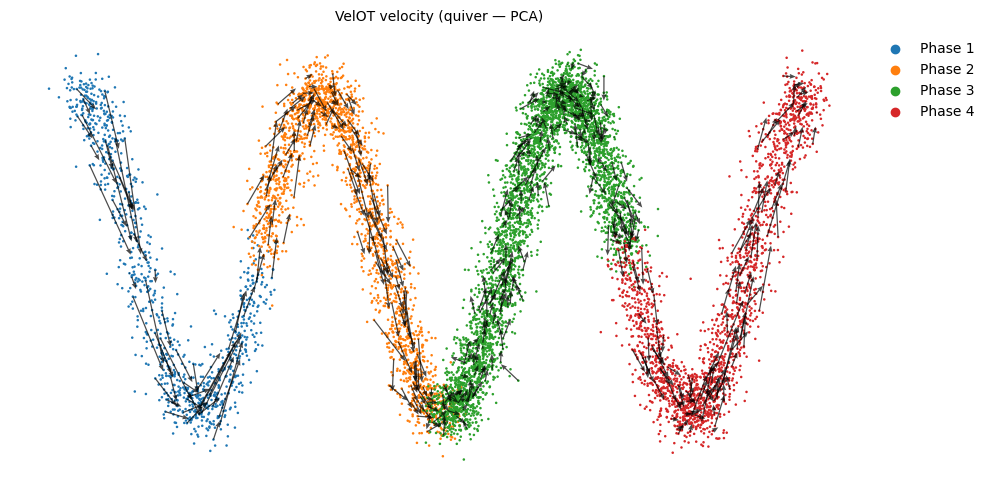

In [5]:
velot.pl.velocity_quiver(adata, color="celltype", basis="pca", subsample=500, figsize=(10,5), velocity_key="velot_velocity_raw", show=False)

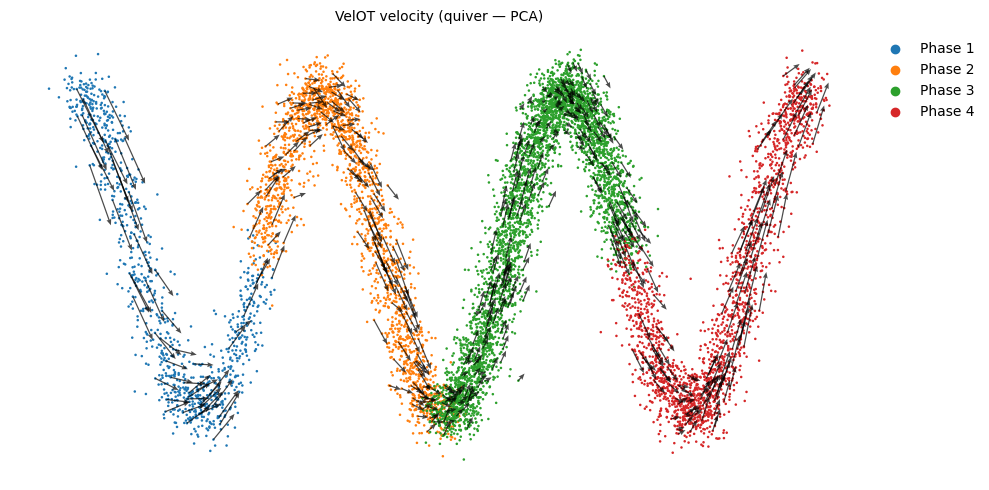

In [6]:
velot.pl.velocity_quiver(adata, color="celltype", basis="pca", subsample=500, figsize=(10,5), velocity_key="velot_velocity", show=False)

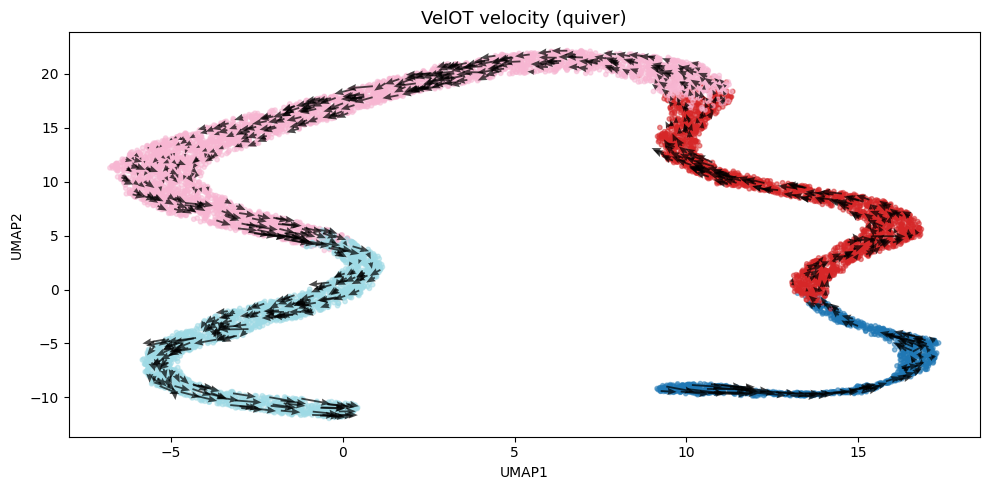

In [13]:
velot.pl.velocity_quiver(adata, color="celltype", basis="umap", subsample=800, figsize=(10,5), velocity_key="velocity_umap", show=False)

  Total: 10 trajectories (forward) from 'Phase_1'
  Using continuous velocity field (neural network)
  Forward — Terminal clusters: {np.str_('Phase_4'): np.int64(10)}


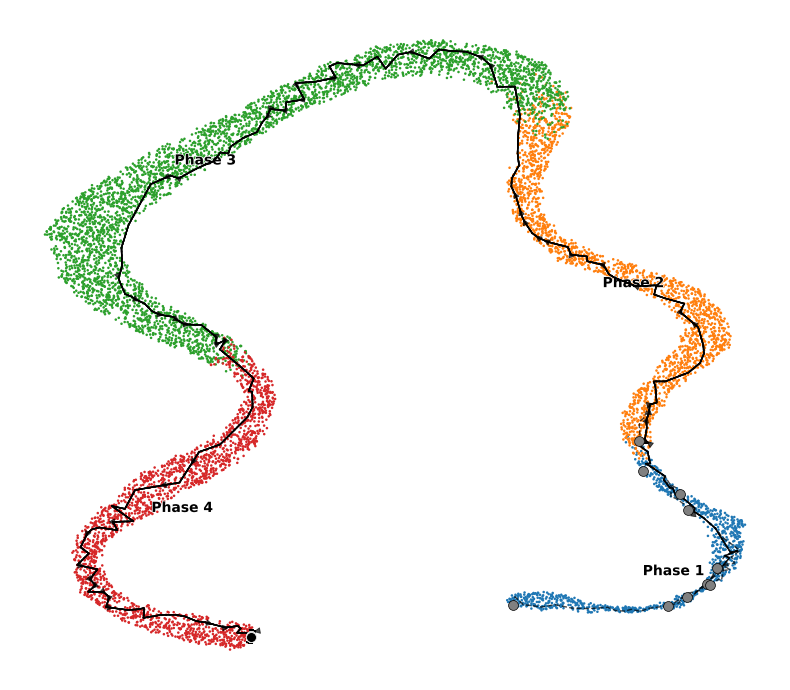

In [5]:
# # Trajectories using the continuous field with evolving pseudotime
velot.tl.compute_trajectories(
    adata,
    basis="X_pca",
    start_cluster="Phase_1",
    # target_cluster="Ngn3 high EP",
    direction="forward",
    velocity_key="velot_velocity",
    use_network=True,
    evolve_pseudotime=True,
    n_trajectories=10,
    cluster_key="celltype",
    n_steps=5000, step_size=1.5, k_velocity=50
)
# velot.pl.trajectories(adata, color="celltype", save=f"{figures_path}/figure2_i.png")

velot.pl.trajectories(adata, color="celltype", show=False, basis="umap")

  Starting cells: 226 candidates (pseudotime=[min, 0.050])
  Total: 5 trajectories (forward) from 'None'
  Using continuous velocity field (neural network)
  Forward — Terminal clusters: {np.str_('Phase_4'): np.int64(5)}


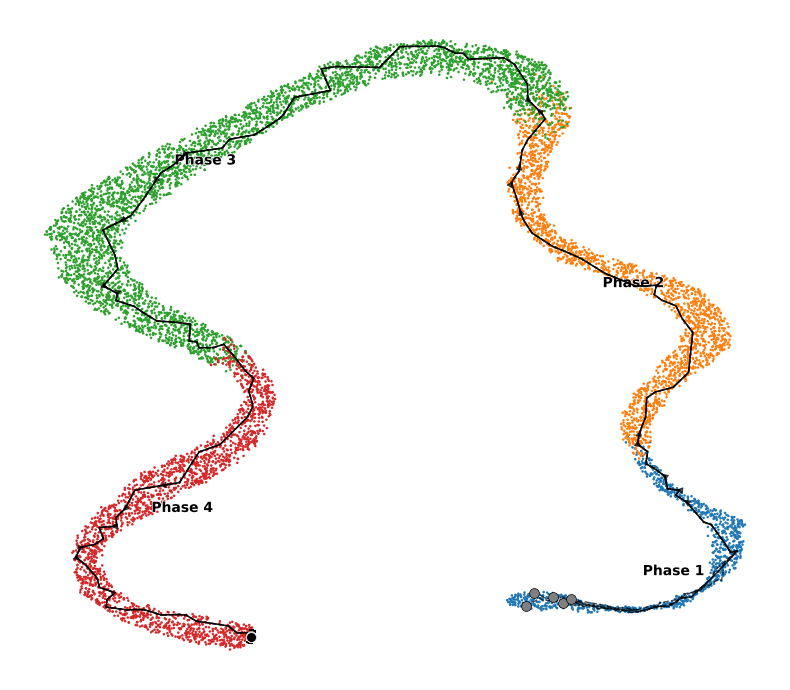

In [14]:
# # Trajectories using the continuous field with evolving pseudotime
velot.tl.compute_trajectories(
    adata,
    basis="X_pca",
    end_pseudotime=0.05,
    # target_cluster="Ngn3 high EP",
    direction="forward",
    velocity_key="velot_velocity",
    use_network=True,
    evolve_pseudotime=True,
    n_trajectories=5,
    cluster_key="celltype",
    n_steps=6000, step_size=2, k_velocity=50
)
# velot.pl.trajectories(adata, color="celltype", save=f"{figures_path}/figure2_i.png")

velot.pl.trajectories(adata, color="celltype", show=False, basis="umap")

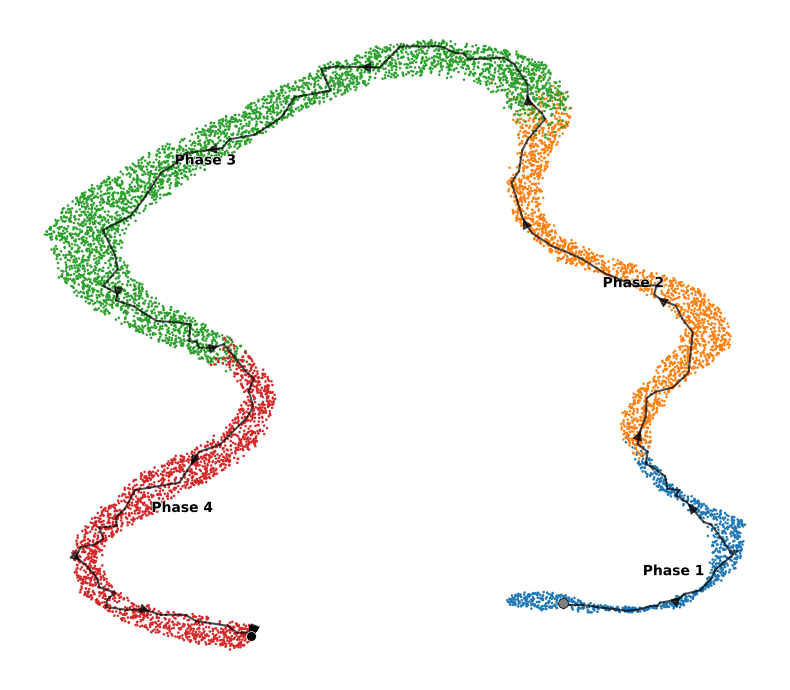

In [25]:
velot.pl.trajectories(
    adata, color="celltype", line_width=1.5, line_style="-", arrow_frequency=10,
    arrow_size=15,
    show=False, basis="umap", trajectory_ids=[0])

In [6]:
adata

AnnData object with n_obs × n_vars = 9000 × 4
    obs: 'celltype', 'true_pseudotime', 'pseudotime', 'clusters_id', 'velot_spatial_cluster', 'velot_confidence'
    uns: 'neighbors', 'pca', 'umap', 'velot_windows', 'velot_smoothing', 'velot_trajectories', 'celltype_colors'
    obsm: 'X_pca', 'X_spatial_true', 'X_umap', 'velot_velocity', 'velot_velocity_raw', 'velocity_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [8]:
adata.uns["velot_trajectories"].keys()

dict_keys(['paths_pca', 'paths_umap', 'metadata', 'start_cluster', 'target_cluster', 'direction', 'n_trajectories', 'n_steps', 'step_size', 'used_network', 'evolved_pseudotime'])

In [15]:
for cell in adata.uns["velot_trajectories"]["metadata"]:
    print(cell["start_cell"])

31
821
546
902
655
